In [71]:
%conda install -c conda-forge lightgbm


6751.16s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Retrieving notices: done
Channels:
 - conda-forge
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 25.7.0

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /homes/nfs/ben/miniconda3/envs/kaggle

  added / updated specs:
    - lightgbm


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    blas-2.131                 |         openblas          16 KB  conda-forge
    blas-devel-3.9.0           |31_h1ea3ea9_openblas          16 KB  conda-forge
    ca-certificates-2025.8.3   |       hbd8a1cb_0         151 KB  conda-forge
    libblas-3.9.0              |31_h59b9bed_openblas          16 KB  conda-forge
    libcblas-3.9.0             |31_he106b2a_openblas          16 KB  conda-forge
    libgfortran-ng-13.2.0      |  

In [ ]:
%pip install xgboost imbalanced-learn -q

6645.74s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


  error: subprocess-exited-with-error
  
  × Building wheel for lightgbm (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [33 lines of output]
      2025-09-28 22:31:38,225 - scikit_build_core - INFO - RUN: /tmp/pip-build-env-ymybdj4g/normal/lib/python3.12/site-packages/cmake/data/bin/cmake -E capabilities
      2025-09-28 22:31:38,236 - scikit_build_core - INFO - CMake version: 4.1.0
      *** scikit-build-core 0.11.6 using CMake 4.1.0 (wheel)
      2025-09-28 22:31:38,239 - scikit_build_core - INFO - Implementation: cpython linux on x86_64
      2025-09-28 22:31:38,257 - scikit_build_core - INFO - Build directory: /tmp/tmpvsh50fe3/build
      *** Configuring CMake...
      2025-09-28 22:31:38,305 - scikit_build_core - INFO - RUN: ninja --version
      2025-09-28 22:31:38,312 - scikit_build_core - INFO - Ninja version: 1.13.0
      2025-09-28 22:31:38,316 - scikit_build_core - INFO - RUN: /tmp/pip-build-env-ymybdj4g/normal/lib/python3.12/site-packages/cmake/data/bin/c

In [49]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import xgboost as xgb
from tqdm import tqdm
import numpy as np

In [60]:
df_txn = pd.read_csv("../data/acct_transaction.csv")
df_alert = pd.read_csv("../data/acct_alert.csv")

## 特徵工程

In [ ]:
def build_features(df_txn):
    acct_features = df_txn.groupby("from_acct").agg(
        txn_count=("txn_amt", "count"),
        txn_sum=("txn_amt", "sum"),
        txn_mean=("txn_amt", "mean"),
        txn_max=("txn_amt", "max"),
        to_acct_unique=("to_acct", "nunique"),
    ).reset_index()

    # 金額波動 & 大額比例
    acct_features["txn_amt_std"] = df_txn.groupby("from_acct")["txn_amt"].std().fillna(0)
    acct_features["txn_large_ratio"] = (
        df_txn.assign(is_large=df_txn["txn_amt"] > 100000)
        .groupby("from_acct")["is_large"].mean()
    )

    # 通路類型 (one-hot)
    channel_dummies = pd.get_dummies(df_txn["channel_type"], prefix="channel")
    df_txn = pd.concat([df_txn, channel_dummies], axis=1)
    acct_channel = df_txn.groupby("from_acct")[channel_dummies.columns].mean()
    acct_features = acct_features.merge(acct_channel, on="from_acct", how="left")

    # 跨行比例
    acct_features["cross_bank_ratio"] = (
        df_txn.assign(cross=(df_txn["to_acct_type"] == "02"))
        .groupby("from_acct")["cross"].mean()
    )

    # 活躍天數 + 夜間比例
    df_txn["txn_time"] = pd.to_datetime(
        df_txn["txn_time"], format="%H%M", errors="coerce"
    ).dt.hour
    df_txn["night"] = df_txn["txn_time"].apply(lambda h: (h >= 22) or (h < 6))
    acct_features["active_days"] = df_txn.groupby("from_acct")["txn_date"].nunique()
    acct_features["night_ratio"] = df_txn.groupby("from_acct")["night"].mean()

    # 熵
    counts = df_txn.groupby(["from_acct", "to_acct"]).size().reset_index(name="cnt")
    total = counts.groupby("from_acct")["cnt"].transform("sum")
    counts["p"] = counts["cnt"] / total
    entropy_df = counts.groupby("from_acct").apply(
        lambda g: -(g["p"] * np.log2(g["p"])).sum()
    )
    acct_features["to_acct_entropy"] = entropy_df

    return acct_features


In [52]:
def build_train_data(acct_features, df_alert):
    df_alert = df_alert.rename(columns={"acct": "from_acct"})
    train_data = acct_features.merge(df_alert, on="from_acct", how="left")
    train_data["label"] = train_data["event_date"].notna().astype(int)
    train_data["event_date"] = train_data["event_date"].fillna(-1).astype(int)
    train_data = train_data.fillna(0)  # 缺失補 0
    return train_data

In [53]:
from sklearn.model_selection import train_test_split


def prepare_dmatrix(train_data):
    X = train_data.drop(columns=["from_acct", "event_date", "label"], errors="ignore")
    y = train_data["label"]

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    
    # 獲取特徵名稱列表
    feature_names = X_train.columns.tolist()

    # 轉 float32 + numpy
    dtrain = xgb.DMatrix(X_train.values.astype("float32"), label=y_train.values, feature_names=feature_names)
    dval = xgb.DMatrix(X_val.values.astype("float32"), label=y_val.values, feature_names=feature_names)

    return dtrain, dval, X_train, X_val, y_train, y_val

In [54]:
from tqdm import tqdm
from xgboost.callback import TrainingCallback


class TQDMCallback(TrainingCallback):
    def __init__(self, total):
        self.pbar = tqdm(total=total, desc="Training XGBoost")

    def after_iteration(self, model, epoch, evals_log):
        self.pbar.update(1)
        return False

    def after_training(self, model):
        self.pbar.close()
        return model


def train_xgb(dtrain, dval, scale_pos_weight):
    params = {
        "objective": "binary:logistic",
        "max_depth": 6,
        "eta": 0.1,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "scale_pos_weight": scale_pos_weight,
        "eval_metric": ["auc", "aucpr"],
        "seed": 42,
    }
    num_round = 300
    evals = [(dtrain, "train"), (dval, "val")]

    bst = xgb.train(
        params,
        dtrain,
        num_boost_round=num_round,
        evals=evals,
        verbose_eval=False,
        callbacks=[TQDMCallback(num_round)],
    )
    return bst

In [55]:
# 特徵工程
acct_features = build_features(df_txn)

# 合併標籤
train_data = build_train_data(acct_features, df_alert)



/tmp/ipykernel_38306/3220669882.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  entropy_df = counts.groupby("from_acct").apply(


In [56]:
# 切分 + DMatrix
dtrain, dval, X_train, X_val, y_train, y_val = prepare_dmatrix(train_data)

# 計算正負樣本比例
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print("scale_pos_weight:", scale_pos_weight)

# 訓練
bst = train_xgb(dtrain, dval, scale_pos_weight)

scale_pos_weight: 1066.6205211726385


Training XGBoost: 100%|██████████| 300/300 [00:15<00:00, 19.57it/s]


In [57]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
)

# 驗證集預測
y_proba = bst.predict(dval)
y_pred = (y_proba > 0.5).astype(int)

print("分類報告 (threshold=0.5):")
print(classification_report(y_val, y_pred, digits=4))

print("ROC-AUC:", roc_auc_score(y_val, y_proba))
print("PR-AUC:", average_precision_score(y_val, y_proba))  # 對 imbalanced data 特別重要

分類報告 (threshold=0.5):
              precision    recall  f1-score   support

           0     0.9994    0.9455    0.9717    163727
           1     0.0071    0.4183    0.0140       153

    accuracy                         0.9450    163880
   macro avg     0.5033    0.6819    0.4929    163880
weighted avg     0.9985    0.9450    0.9708    163880

ROC-AUC: 0.8337694570561046
PR-AUC: 0.006820441731971776


In [58]:
for th in [0.5, 0.3, 0.1]:
    y_pred_th = (y_proba > th).astype(int)
    print(f"\nThreshold = {th}")
    print(classification_report(y_val, y_pred_th, digits=4))


Threshold = 0.5
              precision    recall  f1-score   support

           0     0.9994    0.9455    0.9717    163727
           1     0.0071    0.4183    0.0140       153

    accuracy                         0.9450    163880
   macro avg     0.5033    0.6819    0.4929    163880
weighted avg     0.9985    0.9450    0.9708    163880


Threshold = 0.3
              precision    recall  f1-score   support

           0     0.9995    0.8935    0.9436    163727
           1     0.0050    0.5686    0.0098       153

    accuracy                         0.8932    163880
   macro avg     0.5023    0.7311    0.4767    163880
weighted avg     0.9986    0.8932    0.9427    163880


Threshold = 0.1
              precision    recall  f1-score   support

           0     0.9997    0.7959    0.8862    163727
           1     0.0033    0.7255    0.0066       153

    accuracy                         0.7958    163880
   macro avg     0.5015    0.7607    0.4464    163880
weighted avg     0.9987

Top features by importance:
to_acct_unique: 1591.123779296875
channel_UNK: 858.8228149414062
txn_mean: 626.2691650390625
txn_max: 456.2980041503906
channel_99: 440.7548522949219
txn_sum: 431.0543212890625
channel_02: 342.63043212890625
txn_count: 313.93438720703125
channel_01: 307.0184631347656
channel_06: 287.5318908691406
channel_04: 263.3630065917969
channel_03: 238.62217712402344


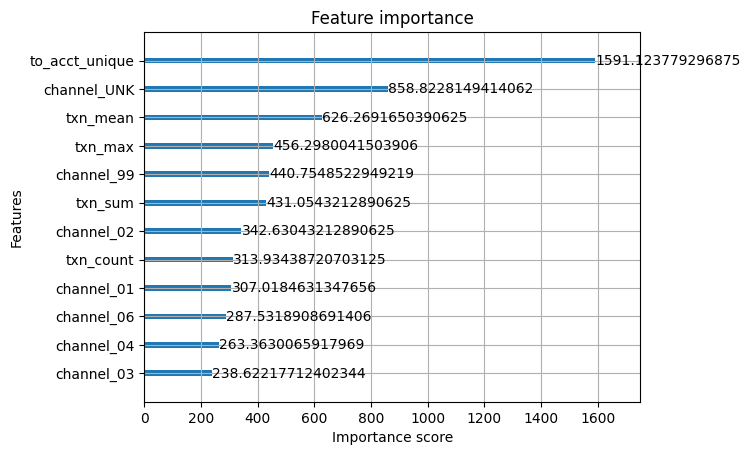

In [59]:
import matplotlib.pyplot as plt


# ========= 特徵重要性 =========
importances = bst.get_score(importance_type="gain")
sorted_features = sorted(importances.items(), key=lambda x: x[1], reverse=True)

print("Top features by importance:")
for feat, score in sorted_features[:20]:
    print(f"{feat}: {score}")

# 畫圖會直接用原始欄位名
xgb.plot_importance(bst, importance_type="gain", max_num_features=20)
plt.show()

          count      mean        std  min  25%  50%  75%    max
label                                                          
0      818632.0  2.708824  11.609205  1.0  1.0  1.0  1.0  497.0
1         767.0  9.641460  22.584058  1.0  2.0  3.0  8.0  384.0


<Axes: xlabel='label', ylabel='to_acct_unique'>

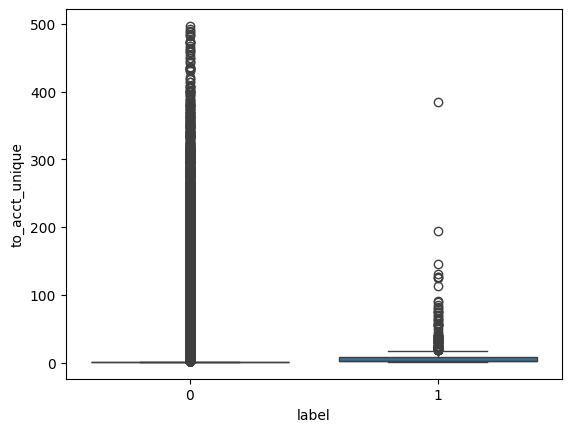

In [62]:
print(train_data.groupby("label")["to_acct_unique"].describe())
import seaborn as sns

sns.boxplot(x="label", y="to_acct_unique", data=train_data)

In [63]:
from sklearn.metrics import f1_score
import numpy as np

thresholds = np.linspace(0.01, 0.5, 50)
f1_scores = [f1_score(y_val, (y_proba > th).astype(int)) for th in thresholds]
best_th = thresholds[np.argmax(f1_scores)]
print("最佳 threshold:", best_th, "F1:", max(f1_scores))

最佳 threshold: 0.47000000000000003 F1: 0.014291307752545028


In [67]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, f1_score, roc_auc_score
import xgboost as xgb
from tqdm import tqdm

# ========= 特徵 / 標籤 =========
X = train_data.drop(columns=["from_acct", "event_date", "label"], errors="ignore")
y = train_data["label"]

# ========= 切分資料集 =========
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ========= SMOTE 過採樣 =========
print("Before SMOTE:", y_train.value_counts())
smote = SMOTE(sampling_strategy=0.5, random_state=42)
# 讓正樣本數量達到負樣本的 50%
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("After SMOTE:", y_train_res.value_counts())

# ========= DMatrix =========
dtrain = xgb.DMatrix(
    X_train_res, label=y_train_res, feature_names=X_train.columns.tolist()
)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=X_val.columns.tolist())

# ========= XGBoost 參數 =========
params = {
    "objective": "binary:logistic",
    "max_depth": 6,
    "eta": 0.1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "eval_metric": "aucpr",
    "seed": 42,
}

num_round = 300
evals = [(dtrain, "train"), (dval, "val")]

# ========= 訓練 =========
bst = xgb.train(
    params,
    dtrain,
    num_boost_round=num_round,
    evals=evals,
    verbose_eval=50,
)

# ========= 驗證 =========
y_proba = bst.predict(dval)

best_f1, best_th = 0, 0
for th in [i / 100 for i in range(1, 100)]:
    y_pred = (y_proba > th).astype(int)
    f1 = f1_score(y_val, y_pred)
    if f1 > best_f1:
        best_f1, best_th = f1, th

print(f"最佳 threshold: {best_th:.2f}, F1: {best_f1:.4f}")
print("ROC-AUC:", roc_auc_score(y_val, y_proba))

# ========= 在最佳 threshold 下的分類報告 =========
y_pred = (y_proba > best_th).astype(int)
print(classification_report(y_val, y_pred))

Before SMOTE: label
0    654905
1       614
Name: count, dtype: int64
After SMOTE: label
0    654905
1    327452
Name: count, dtype: int64
[0]	train-aucpr:0.93196	val-aucpr:0.01053
[50]	train-aucpr:0.96557	val-aucpr:0.01744
[100]	train-aucpr:0.97596	val-aucpr:0.01728
[150]	train-aucpr:0.98190	val-aucpr:0.01619
[200]	train-aucpr:0.98551	val-aucpr:0.01519
[250]	train-aucpr:0.98807	val-aucpr:0.01382
[299]	train-aucpr:0.98972	val-aucpr:0.01332
最佳 threshold: 0.93, F1: 0.0491
ROC-AUC: 0.8462926150261847
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    163727
           1       0.04      0.07      0.05       153

    accuracy                           1.00    163880
   macro avg       0.52      0.54      0.52    163880
weighted avg       1.00      1.00      1.00    163880



In [68]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# ========= 模型輸出 =========
y_proba = bst.predict(dval)  # validation set 機率
y_true = y_val.values


# ========= Top-k 評估函數 =========
def evaluate_topk(y_true, y_proba, k_list=[100, 500, 1000, 2000]):
    results = {}
    sorted_idx = np.argsort(-y_proba)  # 機率由高到低排序
    for k in k_list:
        topk_idx = sorted_idx[:k]
        y_pred = np.zeros_like(y_true)
        y_pred[topk_idx] = 1
        precision = precision_score(y_true, y_pred)
        recall = recall_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        results[k] = {"precision": precision, "recall": recall, "f1": f1}
    return results


# ========= 測試不同 k =========
k_results = evaluate_topk(y_true, y_proba, k_list=[100, 500, 1000, 2000, 5000])
for k, metrics in k_results.items():
    print(f"\nTop-{k}")
    print(metrics)


Top-100
{'precision': 0.03, 'recall': 0.0196078431372549, 'f1': 0.023715415019762844}

Top-500
{'precision': 0.028, 'recall': 0.0915032679738562, 'f1': 0.042879019908116385}

Top-1000
{'precision': 0.02, 'recall': 0.13071895424836602, 'f1': 0.03469210754553339}

Top-2000
{'precision': 0.014, 'recall': 0.1830065359477124, 'f1': 0.026010218300046448}

Top-5000
{'precision': 0.0106, 'recall': 0.3464052287581699, 'f1': 0.020570541432175432}


In [73]:
from tqdm import tqdm

# ========== 建立帳戶特徵 ==========
print("Building features...")
acct_features = (
    df_txn.groupby("from_acct")
    .agg(
        txn_count=("txn_amt", "count"),
        txn_sum=("txn_amt", "sum"),
        txn_mean=("txn_amt", "mean"),
        txn_max=("txn_amt", "max"),
        to_acct_unique=("to_acct", "nunique"),
        channel_unique=("channel_type", "nunique"),
    )
    .reset_index()
)

# ========== 加入大額比例 ==========
print("Adding large transaction ratio...")
acct_features["txn_amt_std"] = df_txn.groupby("from_acct")["txn_amt"].std().fillna(0)
acct_features["txn_large_ratio"] = (
    df_txn.assign(is_large=df_txn["txn_amt"] > 100000)
    .groupby("from_acct")["is_large"]
    .mean()
)

Building features...
Adding large transaction ratio...


In [74]:
# ========== 通路 one-hot ==========
print("Adding channel dummies...")
channel_dummies = pd.get_dummies(df_txn["channel_type"], prefix="channel")
df_txn = pd.concat([df_txn, channel_dummies], axis=1)
acct_channel = df_txn.groupby("from_acct")[channel_dummies.columns].mean()
acct_features = acct_features.merge(acct_channel, on="from_acct", how="left")

# ========== 時間特徵 ==========
print("Adding time features...")
df_txn["txn_time"] = pd.to_numeric(df_txn["txn_time"], errors="coerce")
df_txn["night"] = df_txn["txn_time"].apply(
    lambda t: (t >= 2200) or (t < 600) if pd.notna(t) else False
)

acct_features["active_days"] = df_txn.groupby("from_acct")["txn_date"].nunique()
acct_features["night_ratio"] = df_txn.groupby("from_acct")["night"].mean()

# 熵特徵
print("Adding entropy...")
counts = df_txn.groupby(["from_acct", "to_acct"]).size().reset_index(name="cnt")
total = counts.groupby("from_acct")["cnt"].transform("sum")
counts["p"] = counts["cnt"] / total
entropy_df = counts.groupby("from_acct").apply(
    lambda g: -(g["p"] * np.log2(g["p"])).sum()
)
acct_features["to_acct_entropy"] = entropy_df

Adding channel dummies...
Adding time features...
Adding entropy...


/tmp/ipykernel_38306/2498030605.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  entropy_df = counts.groupby("from_acct").apply(


In [75]:
# ========== Label ==========
print("Merging labels...")
df_alert = df_alert.rename(columns={"acct": "from_acct"})
train_data = acct_features.merge(df_alert, on="from_acct", how="left")
train_data["label"] = train_data["event_date"].notna().astype(int)
train_data = train_data.fillna(0)

print(train_data[["label"]].value_counts())

Merging labels...
label
0        818632
1           767
Name: count, dtype: int64


In [76]:
from sklearn.model_selection import train_test_split
import xgboost as xgb

# ========= 切分資料 =========
X = train_data.drop(columns=["from_acct", "event_date", "label"], errors="ignore")
y = train_data["label"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ========= DMatrix =========
dtrain = xgb.DMatrix(X_train.astype("float32"), label=y_train)
dval = xgb.DMatrix(X_val.astype("float32"), label=y_val)

In [77]:
from xgboost.callback import TrainingCallback


class TQDMCallback(TrainingCallback):
    def __init__(self, total):
        self.pbar = tqdm(total=total, desc="Training XGBoost")

    def after_iteration(self, model, epoch, evals_log):
        self.pbar.update(1)
        return False

    def after_training(self, model):
        self.pbar.close()
        return model


params = {
    "objective": "binary:logistic",
    "max_depth": 6,
    "eta": 0.1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "eval_metric": "aucpr",
    "seed": 42,
}

num_round = 300
evals = [(dtrain, "train"), (dval, "val")]

bst = xgb.train(
    params,
    dtrain,
    num_boost_round=num_round,
    evals=evals,
    verbose_eval=False,
    callbacks=[TQDMCallback(num_round)],
)

Training XGBoost: 100%|██████████| 300/300 [00:09<00:00, 30.61it/s]


In [78]:
import numpy as np
from sklearn.metrics import f1_score, classification_report, roc_auc_score

# 驗證集預測
y_proba = bst.predict(dval)

# 掃一遍 threshold
best_f1, best_th = 0, 0
for th in np.linspace(0.01, 0.99, 99):
    y_pred = (y_proba > th).astype(int)
    f1 = f1_score(y_val, y_pred)
    if f1 > best_f1:
        best_f1, best_th = f1, th

print(f"最佳 threshold: {best_th:.2f}, F1: {best_f1:.4f}")
print("ROC-AUC:", roc_auc_score(y_val, y_proba))

# 最佳 threshold 下的分類報告
y_pred = (y_proba > best_th).astype(int)
print(classification_report(y_val, y_pred))

最佳 threshold: 0.06, F1: 0.0485
ROC-AUC: 0.8831957477757391
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    163727
           1       0.05      0.05      0.05       153

    accuracy                           1.00    163880
   macro avg       0.52      0.53      0.52    163880
weighted avg       1.00      1.00      1.00    163880



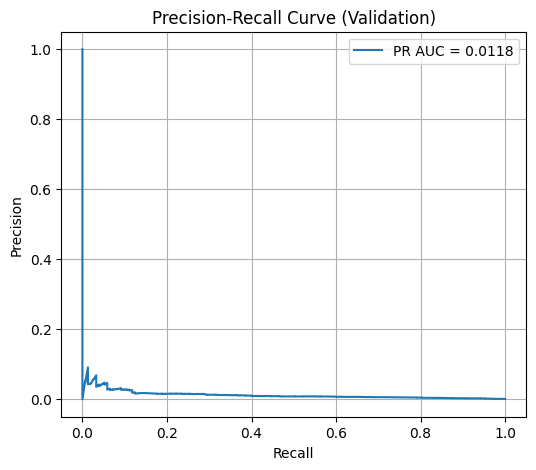

In [79]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

precision, recall, thresholds = precision_recall_curve(y_val, y_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Validation)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import lightgbm as lgb
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    precision_recall_curve,
    auc,
)
import numpy as np
import matplotlib.pyplot as plt
from lightgbm import early_stopping, log_evaluation

# ========= 建立 LightGBM Dataset =========
dtrain = lgb.Dataset(X_train, label=y_train)
dval = lgb.Dataset(X_val, label=y_val, reference=dtrain)

params = {
    "objective": "binary",
    "metric": ["auc", "average_precision"],  # AUC & PR-AUC
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 64,
    "max_depth": -1,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "scale_pos_weight": scale_pos_weight,  # 跟 XGB 一樣處理 imbalance
    "seed": 42,
    "verbosity": -1,
}

num_round = 500
bst = lgb.train(
    params,
    dtrain,
    num_boost_round=num_round,
    valid_sets=[dtrain, dval],
    valid_names=["train", "val"],
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(period=50),
    ],
)

# ========= 驗證 =========
y_proba = bst.predict(X_val, num_iteration=bst.best_iteration)
y_pred = (y_proba > 0.5).astype(int)

print("分類報告 (threshold=0.5)：")
print(classification_report(y_val, y_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_proba))

# ========= 找最佳 threshold =========
prec, rec, thresholds = precision_recall_curve(y_val, y_proba)
f1_scores = 2 * prec * rec / (prec + rec + 1e-9)
best_idx = np.argmax(f1_scores)
print("最佳 threshold:", thresholds[best_idx], "F1:", f1_scores[best_idx])

# ========= 畫 PR Curve =========
plt.figure()
plt.plot(rec, prec, label=f"PR AUC = {auc(rec, prec):.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Validation)")
plt.legend()
plt.show()

# ========= 特徵重要性 =========
lgb.plot_importance(bst, max_num_features=20, importance_type="gain")
plt.show()

TypeError: train() got an unexpected keyword argument 'early_stopping_rounds'